## Import Libraries

In [1]:
import os

os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"

In [2]:
import numpy as np

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

## Prepare train dataset

In [3]:
# Transform to turn into tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.1307],[0.3081]), # mean y std
    transforms.Lambda( lambda x: (x > 0.5).float() ) # Binarize
])

In [4]:
# Load the dataset and normalize it
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform
)

## Prepare test dataset

In [5]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.1307],[0,3081]),
    transforms.Lambda( lambda x: (x > 0.5).float() )
])

In [6]:
# Load the test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

## Data Examples

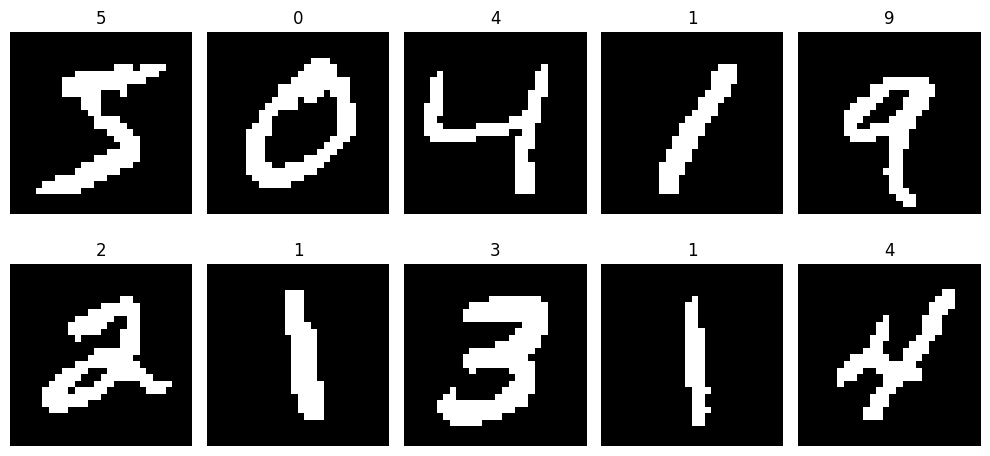

In [7]:
fig, axes = plt.subplots(2,5,figsize=(10,5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    image_np = image.squeeze().numpy()

    ax.imshow(image_np, cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Data Loaders

In [8]:
# DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=512,
    num_workers=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=1028,
    num_workers=4,
    shuffle=True,
    drop_last=False
)

## Feed Forward Network 

In [9]:
# All variables
%whos

Variable         Type          Data/Info
----------------------------------------
DataLoader       type          <class 'torch.utils.data.dataloader.DataLoader'>
F                module        <module 'torch.nn.functio<...>/torch/nn/functional.py'>
ax               Axes          Axes(0.803,0.0842011;0.182x0.364)
axes             ndarray       2x5: 10 elems, type `object`, 80 bytes
datasets         module        <module 'torchvision.data<...>on/datasets/__init__.py'>
fig              Figure        Figure(1000x500)
i                int           9
image            Tensor        tensor([[[0., 0., 0., 0.,<...>., 0., 0., 0., 0., 0.]]])
image_np         ndarray       28x28: 784 elems, type `float32`, 3136 bytes
label            int           4
nn               module        <module 'torch.nn' from '<...>es/torch/nn/__init__.py'>
np               module        <module 'numpy' from '/ho<...>kages/numpy/__init__.py'>
os               module        <module 'os' (frozen)>
plt              module 

In [10]:
import torch

print(f"¿GPU disponible?: {torch.cuda.is_available()}")
print(f"Nombre de la GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Ninguna'}")

¿GPU disponible?: True
Nombre de la GPU: AMD Radeon RX 6600


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

Entrenando en: cuda


In [12]:
def createTheMNISTNet():

    class mnistNet(nn.Module):
        def __init__(self):
            super().__init__()

            # input layer
            self.input = nn.Linear(784,64) # 784 pixels

            # hidden layer
            self.fc1 = nn.Linear(64,32)
            self.fc2 = nn.Linear(32,32)

            # output layer
            self.output = nn.Linear(32,10)

        def forward(self,x):
            x = x.view(x.shape[0], -1)
            
            x = F.relu( self.input(x) )
            x = F.relu( self.fc1(x) )
            x = F.relu( self.fc2(x) )
            return torch.log_softmax( self.output(x), dim=1 )

    net = mnistNet()

    lossfun = nn.NLLLoss()

    optimizer = torch.optim.SGD(net.parameters(), lr=0.1) # try with Adam later

    return net, lossfun, optimizer

Model Summary
mnistNet(
  (input): Linear(in_features=784, out_features=64, bias=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=10, bias=True)
)

Input Layer Summary
{'training': True, '_parameters': {'weight': Parameter containing:
tensor([[-0.0114,  0.0324, -0.0263,  ...,  0.0153, -0.0159, -0.0098],
        [ 0.0327,  0.0283,  0.0171,  ...,  0.0159,  0.0279,  0.0115],
        [-0.0274, -0.0086,  0.0112,  ...,  0.0246,  0.0290,  0.0209],
        ...,
        [-0.0265,  0.0304,  0.0326,  ...,  0.0171, -0.0159, -0.0089],
        [-0.0030,  0.0129, -0.0024,  ..., -0.0149,  0.0341, -0.0209],
        [-0.0257, -0.0008,  0.0156,  ...,  0.0026, -0.0330,  0.0089]],
       requires_grad=True), 'bias': Parameter containing:
tensor([ 0.0239, -0.0267,  0.0288,  0.0033, -0.0058,  0.0338,  0.0016,  0.0080,
         0.0089,  0.0038, -0.0205,  0.0095,  0.0036,  0.0275, -0.004

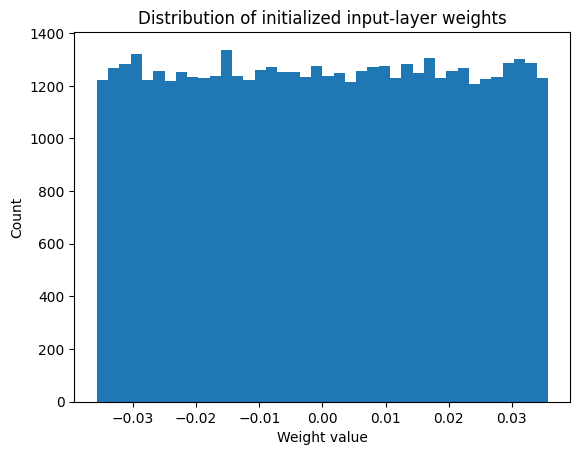

In [13]:
net = createTheMNISTNet()[0] 

print('Model Summary')
print(net, end="\n\n")

print('Input Layer Summary')
print(vars(net.input), end="\n\n")

print('Input Layer Weights')
print(net.input.weight.shape)
print(net.input.weight)

w = net.input.weight.detach().flatten()
plt.hist(w, 40)
plt.xlabel('Weight value')
plt.ylabel('Count')
plt.title('Distribution of initialized input-layer weights')
plt.show()

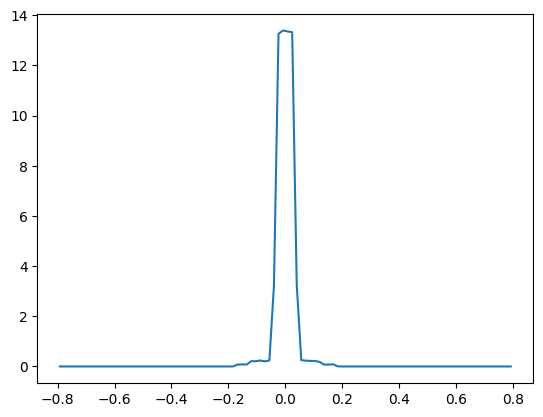

In [14]:
def weightsHistogram(net):

    W = np.array([])

    for name, param in net.named_parameters():
        W = np.concatenate( (W, param.detach().cpu().flatten().numpy()) )

    histy, histx = np.histogram(W, bins=np.linspace(-0.8,0.8,101), density=True)
    histx = (histx[1:]+histx[:-1])/2
    return histx, histy

histx, histy = weightsHistogram(net)
plt.plot(histx, histy)